In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier

# create synthetic academic dataset
np.random.seed(42)

data = pd.DataFrame({
    "Student_ID": range(1,201),
    "Study_Hours": np.random.randint(1,10,200),
    "Attendance": np.random.randint(50,100,200),
    "Assignments": np.random.randint(40,100,200),
    "Internal_Marks": np.random.randint(30,100,200),
    "Previous_GPA": np.round(np.random.uniform(5,10,200),2),
})

# performance score
data["Final_Score"] = (
    data["Study_Hours"]*5 +
    data["Attendance"]*0.3 +
    data["Assignments"]*0.4 +
    data["Internal_Marks"]*0.5 +
    data["Previous_GPA"]*2
)

data["Result"] = np.where(data["Final_Score"]>120,"Pass","Fail")

data.head()


,Student_ID,Study_Hours,Attendance,Assignments,Internal_Marks,Previous_GPA,Final_Score,Result
0,1,7,50,48,71,7.74,120.18,Pass
1,2,4,60,51,87,7.67,117.24,Fail
2,3,8,77,92,68,6.78,147.46,Pass
3,4,5,74,40,43,9.47,103.64,Fail
4,5,7,99,97,34,5.64,131.78,Pass


In [2]:
conditions = [
    data["Final_Score"] >= 140,
    (data["Final_Score"] >= 110) & (data["Final_Score"] < 140),
    data["Final_Score"] < 110
]

choices = ["Low Risk", "Medium Risk", "High Risk"]

data["Risk_Level"] = np.select(conditions, choices, default="Medium Risk")

data.head()

,Student_ID,Study_Hours,Attendance,Assignments,Internal_Marks,Previous_GPA,Final_Score,Result,Risk_Level
0,1,7,50,48,71,7.74,120.18,Pass,Medium Risk
1,2,4,60,51,87,7.67,117.24,Fail,Medium Risk
2,3,8,77,92,68,6.78,147.46,Pass,Low Risk
3,4,5,74,40,43,9.47,103.64,Fail,High Risk
4,5,7,99,97,34,5.64,131.78,Pass,Medium Risk


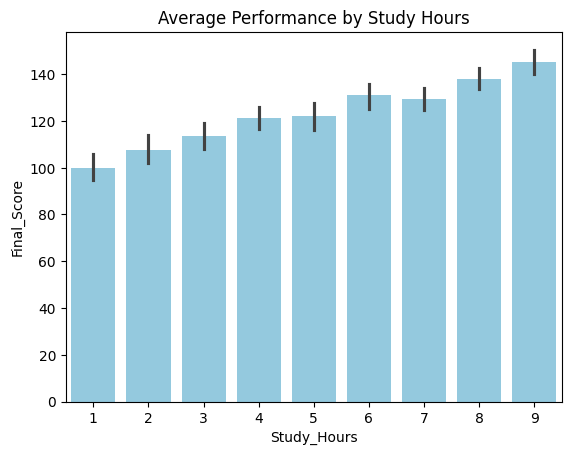

In [3]:
import seaborn as sns

plt.figure()

sns.barplot(x="Study_Hours", y="Final_Score", data=data,color="skyBlue")

plt.title("Average Performance by Study Hours")

plt.show()

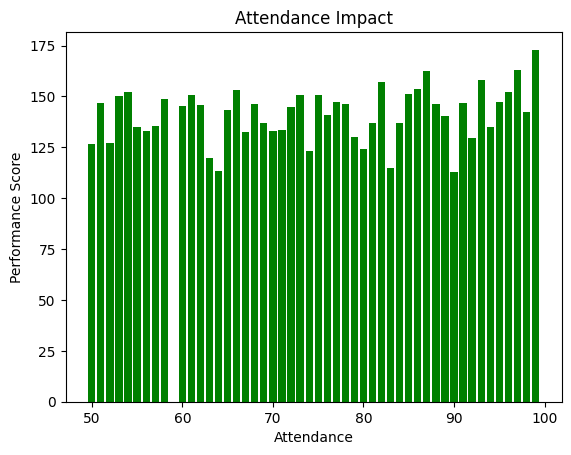

In [4]:
# Attendance impact
import pandas as pd
import matplotlib.pyplot as plt
plt.figure()
plt.bar(data["Attendance"], data["Final_Score"],color="green")
plt.xlabel("Attendance")
plt.ylabel("Performance Score")
plt.title("Attendance Impact")
plt.show()

In [5]:
data["Result"] = data["Final_Score"].apply(lambda x: "Pass" if x >= 120 else "Fail")

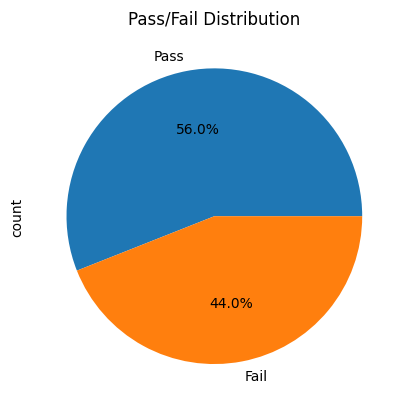

In [6]:
# Result distribution
plt.figure()
data["Result"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Pass/Fail Distribution")
plt.show()


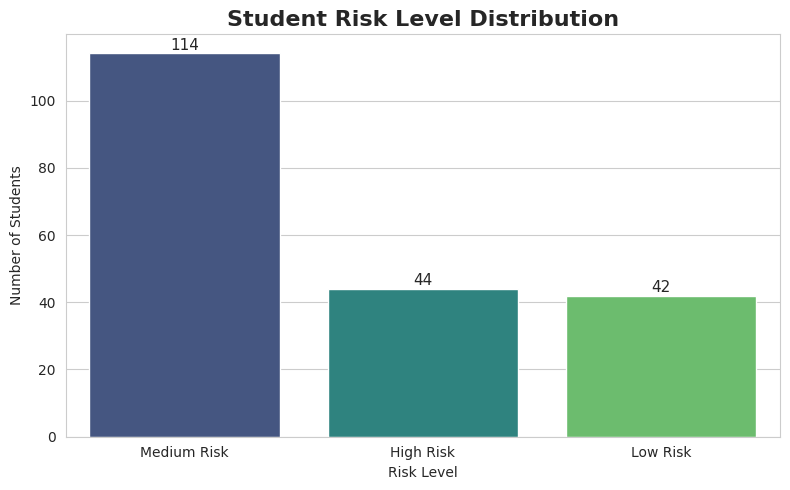

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

risk_counts = data["Risk_Level"].value_counts()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values,
    hue=risk_counts.index,
    palette="viridis",
    legend=False
)

plt.title("Student Risk Level Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Risk Level")
plt.ylabel("Number of Students")

# value labels
for i, v in enumerate(risk_counts.values):
    ax.text(i, v + 1, str(v), ha="center", fontsize=11)

plt.tight_layout()
plt.show()


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


X = data[["Study_Hours","Attendance","Assignments","Internal_Marks","Previous_GPA"]]
y = data["Final_Score"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = LinearRegression()
model.fit(X_train,y_train)

predictions = model.predict(X_test)

print("Model Accuracy:", model.score(X_test,y_test))


Model Accuracy: 1.0


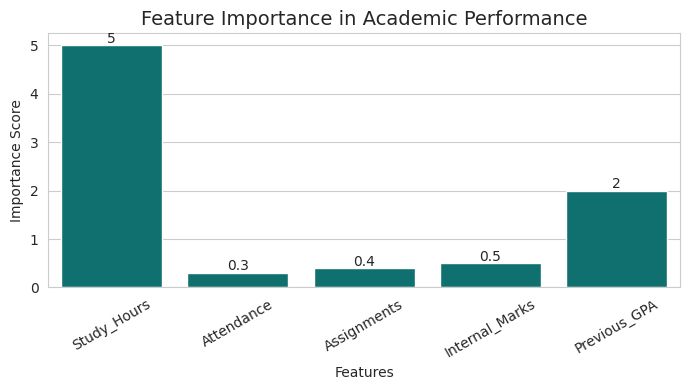

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ["Study_Hours","Attendance","Assignments","Internal_Marks","Previous_GPA"]
importance = [5,0.3,0.4,0.5,2]

plt.figure(figsize=(7,4))

ax = sns.barplot(x=features, y=importance, color="teal")

plt.title("Feature Importance in Academic Performance", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=30)

# add value labels
for i, v in enumerate(importance):
    ax.text(i, v + 0.05, str(v), ha='center')

plt.tight_layout()
plt.show()

In [10]:
def student_prediction(hours, attendance, assignments, internal, gpa):
    pred = model.predict([[hours,attendance,assignments,internal,gpa]])
    print("Predicted Final Score:", pred[0])

student_prediction(7,85,80,75,8.5)


Predicted Final Score: 147.00000000000003


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [11]:
from sklearn.tree import DecisionTreeClassifier

y_class = data["Result"]

X_train, X_test, y_train, y_test = train_test_split(X,y_class,test_size=0.2)

clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)

print("Classification Accuracy:", clf.score(X_test,y_test))


Classification Accuracy: 0.75


In [12]:
X_risk = data[["Study_Hours","Attendance","Assignments","Internal_Marks","Previous_GPA"]]
y_risk = data["Risk_Level"]

X_train_risk, X_test_risk, y_train_risk, y_test_risk = train_test_split(
    X_risk, y_risk, test_size=0.2, random_state=42
)

risk_model = DecisionTreeClassifier()

risk_model.fit(X_train_risk, y_train_risk)

print("Risk Detection Accuracy:", risk_model.score(X_test_risk, y_test_risk))

Risk Detection Accuracy: 0.75


In [13]:
def predict_risk(hours, attendance, assignments, internal, gpa):

    student = [[hours, attendance, assignments, internal, gpa]]

    risk = risk_model.predict(student)

    print("Predicted Risk Level:", risk[0])



In [14]:
def predict_risk_with_probability(hours, attendance, assignments, internal, gpa):

    student = [[hours, attendance, assignments, internal, gpa]]

    risk = risk_model.predict(student)

    prob = risk_model.predict_proba(student)

    print("Predicted Risk Level:", risk[0])
    print("Risk Probabilities:", prob)



In [15]:
predict_risk(3,60,50,45,5.5)

predict_risk_with_probability(3,60,50,45,5.5)

Predicted Risk Level: High Risk
Predicted Risk Level: High Risk
Risk Probabilities: [[1. 0. 0.]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
